# Matplotlib y Pandas: Caso practico

En esta unidad vamos a realizar una serie de ejercicios y explicaciones para conocer la libreria de Matplotlib y como esta se relaciona con pandas.

> Matplotlib es una libreria dedicada a la visualizacion de datos, que da base a otras como Seaborn y StatsModels

Vamos a realizar todo el ejercicio utilizando un dataset especifico para ello.

Como hemos visto en el modulo de seaborn tendremos que activar matplotlib para que nos reconozca los titulos, aunque tambien lo importaremos.

In [1]:
%matplotlib inline

In [3]:
#1º cargamos el dataset y comprobamos que se visualiza correctamente

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

Ruta = Path(r"C:\proyecto-faust\M02_Python_Librerias_Big_Data\U2_Libreria_Pandas\Ejercicios_clase_pandas\penguins.csv")
df = pd.read_csv(Ruta)
print(df.head())

  studyName  Sample Number                              Species  Region  \
0   PAL0708              1  Adelie Penguin (Pygoscelis adeliae)  Anvers   
1   PAL0708              2  Adelie Penguin (Pygoscelis adeliae)  Anvers   
2   PAL0708              3  Adelie Penguin (Pygoscelis adeliae)  Anvers   
3   PAL0708              4  Adelie Penguin (Pygoscelis adeliae)  Anvers   
4   PAL0708              5  Adelie Penguin (Pygoscelis adeliae)  Anvers   

      Island               Stage Individual ID Clutch Completion  Date Egg  \
0  Torgersen  Adult, 1 Egg Stage          N1A1               Yes  11/11/07   
1  Torgersen  Adult, 1 Egg Stage          N1A2               Yes  11/11/07   
2  Torgersen  Adult, 1 Egg Stage          N2A1               Yes  11/16/07   
3  Torgersen  Adult, 1 Egg Stage          N2A2               Yes  11/16/07   
4  Torgersen  Adult, 1 Egg Stage          N3A1               Yes  11/16/07   

   Culmen Length (mm)  Culmen Depth (mm)  Flipper Length (mm)  Body Mass (g)  \


El dataset es un estudio de datos de caracteristicas de pingüinos y para entender mejor sus variables, dado que son tecnicas, veremos estas explicaciones aclaratorias:

- *Culmen*: Son las mediciones del pico del pingüino, midiendose el largo y el ancho
- *Delta 15N*/ *Delta 13C*: Niveles de nitrogeno y Carbono
- *Clutch Completion*: Mide si se ha realizado toda la puestada de huevos o no
- *Flipper*: Es la aleta

El conjunto de datos tiene una estructura de *long-form data* por lo que cada linea de la estructura corresponde a una observacion



## 1º Enunciado: Visualizacion basica de los datos

Hay una serie de pautas que tenemos que saber hacer siempre que trabajemos con datos y cumplen estas peticiones

> **Debemos comprender que datos tenemos tenemos, si hay NaN's, ver ejemplos de representacion.... info basica pero necesaria**

- Cargar el dataset
- Mostrar los nombres de las columnas
- Mostras las 5 primeras filas
- Mostrar el total de filas y columnas
- Mostrar informacion general del dataset

In [10]:
#1º cargamos el dataset
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

Ruta = Path(r"C:\proyecto-faust\M02_Python_Librerias_Big_Data\U2_Libreria_Pandas\Ejercicios_clase_pandas\penguins.csv")
df = pd.read_csv(Ruta)

#2º Mostramos el nombre de las columnas - mediante .columns
print(df.columns)
print(100*"_")

#3º Mostramos las 5 primeras filas - mediante .head()
print(df.head())
print( 100*"_")

#4º Mostramos el total de las filasy columnas - mediante .shape
print(df.shape)
print( 100*"_")

#5º Mostramos info general del dataset - mediante .info()
df.info()

Index(['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage',
       'Individual ID', 'Clutch Completion', 'Date Egg', 'Culmen Length (mm)',
       'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex',
       'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)', 'Comments'],
      dtype='object')
____________________________________________________________________________________________________
  studyName  Sample Number                              Species  Region  \
0   PAL0708              1  Adelie Penguin (Pygoscelis adeliae)  Anvers   
1   PAL0708              2  Adelie Penguin (Pygoscelis adeliae)  Anvers   
2   PAL0708              3  Adelie Penguin (Pygoscelis adeliae)  Anvers   
3   PAL0708              4  Adelie Penguin (Pygoscelis adeliae)  Anvers   
4   PAL0708              5  Adelie Penguin (Pygoscelis adeliae)  Anvers   

      Island               Stage Individual ID Clutch Completion  Date Egg  \
0  Torgersen  Adult, 1 Egg Stage          N1A1         

## 2º Enunciado: Gestion de NaNs del dataset

Otro aspecto inicial a realizar antes de ponernos a trabajar con los datos, es gestionar los NaN del dataset.

> **Trabajar primero estos valores no reconocidos, mejorara nuestra capacidad de tratamiento y calculo de todo el dataset, para evitar errores**

- Comprueba el numero de NaN por columna
- Eliminar las columnas *Delta 15N*/ *Delta 13C*
- Completar la columna *Comments* con *No Comments* si hay NaN
- Para las columnas de medidas del piso, aleta y peso, rellenar los NaN con medias del total
- Para la columna *Sex* transformar el tipo a *category* y utilizar el valor que mas se repita de *Male/Female* para rellenar los NaN
- Volver a comprobar los NaN por columna

In [17]:
#1º cargamos el dataset
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

Ruta = Path(r"C:\proyecto-faust\M02_Python_Librerias_Big_Data\U2_Libreria_Pandas\Ejercicios_clase_pandas\penguins.csv")
df = pd.read_csv(Ruta)

#2º Comprobamos los NaN - utilizaremos .isnull() que indica valores nulos por variable y adicionalmente utilizaremos .sum() para recopilarlos en 1 valor.
print(df.isnull().sum())
print( 40*"__")

#3º Eliminamos las columnas - utilizamos .drop() para cada columna. Indicaremos nombre de la vairable y su eje columna.
df = df.drop("Delta 15 N (o/oo)", axis = "columns").drop("Delta 13 C (o/oo)", axis = "columns")

#4º Completamos comments - seleccionamos la columna y modificamos su valor seleccionando la columna + .fillna( con lo que queramos completar)
df["Comments"] = df["Comments"].fillna("No Comments")

#5º Rellenamos la media de las medidas - seleccionamos la columna y modificamos su valor seleccionando la columna + .fillna( colummna. mean())
df["Culmen Length (mm)"] = df["Culmen Length (mm)"].fillna(df["Culmen Length (mm)"].mean())
df["Culmen Depth (mm)"] = df["Culmen Depth (mm)"].fillna(df["Culmen Depth (mm)"].mean())
df["Flipper Length (mm)"] = df["Flipper Length (mm)"].fillna(df["Flipper Length (mm)"].mean())
df["Body Mass (g)"] = df["Body Mass (g)"].fillna(df["Body Mass (g)"].mean())

#6º - 1/2 Cambiamos categoria para sex - seleccionamos la columnas y cambiamos el tipo con .astype("category")
df["Sex"] = df["Sex"].astype("category")

#6º - 2/2 Completamos datos con el valor que mas se repita. 
    # Crearemos una variable con los valores mas repetidos mediante .describe()["top"]
        # .describe() en una variable , nos sacara varios datos y uno de ellos es "top", como el mas repetido.
    # luego incluirlos a la columna mediante .fillna(variable)
sex = df["Sex"].describe()["top"]
df["Sex"] = df["Sex"].fillna(sex)

#7º Volvemos a comprobar los NaN
print(df.isnull().sum())

studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       2
Culmen Depth (mm)        2
Flipper Length (mm)      2
Body Mass (g)            2
Sex                     11
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               318
dtype: int64
________________________________________________________________________________
studyName              0
Sample Number          0
Species                0
Region                 0
Island                 0
Stage                  0
Individual ID          0
Clutch Completion      0
Date Egg               0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
Comments               0
dtype: int64


## 3º Enunciado: Calculos basicos

Una vez el dataset esta listo, podemos realizar algun calculo basico sobre el mismo, como **las medias, porcentajes, recuentos, max o min,...**

> **En este y mas ejercicios, dado que hemos generado un dataframe limpio de NaN, podremos o bien, cargar el script anterior generado o guardarlo en uno nuevo para poder realizar calculos sobre este.**
>
> > Esta 2º opcion no see recomienda salvo que tenga sentido guardar el dataframe ya que podemos generar muchos archivos *basura* en nuestro proceso de gestion de datos.

- Media de ancho y largura del pico, peso y tamalio de la aleta por especie
  > **Siempre que nos pidan extraer un dato o datos *por una variable* hay que utilizar .groupby()**
- % de *"clutch completition"* de una especie en concreto: Chinstrap penguin (Pygoscelis antarctica)
- nº de especies por isla y guardarlos en un nuevo dataframe

In [25]:
#1º cargamos el dataset y modificaciones hechas anteriormente
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

Ruta = Path(r"C:\proyecto-faust\M02_Python_Librerias_Big_Data\U2_Libreria_Pandas\Ejercicios_clase_pandas\penguins.csv")
df = pd.read_csv(Ruta)
df = df.drop("Delta 15 N (o/oo)", axis = "columns").drop("Delta 13 C (o/oo)", axis = "columns")
df["Comments"] = df["Comments"].fillna("No Comments")
df["Culmen Length (mm)"] = df["Culmen Length (mm)"].fillna(df["Culmen Length (mm)"].mean())
df["Culmen Depth (mm)"] = df["Culmen Depth (mm)"].fillna(df["Culmen Depth (mm)"].mean())
df["Flipper Length (mm)"] = df["Flipper Length (mm)"].fillna(df["Flipper Length (mm)"].mean())
df["Body Mass (g)"] = df["Body Mass (g)"].fillna(df["Body Mass (g)"].mean())
df["Sex"] = df["Sex"].astype("category")
sex = df["Sex"].describe()["top"]
df["Sex"] = df["Sex"].fillna(sex)

#2º Agrupamos por especie a traves de .groupby("Species") y calculamos las medias de las columnas [[..]].mean()

medias = df.groupby("Species")[["Culmen Length (mm)", "Culmen Depth (mm)", "Flipper Length (mm)", "Body Mass (g)"]].mean()
print(medias)
print(40*"__")

#3º 1/3 - Cambiamos la variable a category mediante .astype("category")

df["Clutch Completion"]= df["Clutch Completion"].astype("category")

#3º 2/3 - El proceso es:
        #0ª Generamos una variable para contabilizar la frecuencia y otra la cantidad, para posteriormente hacer el calculo de %.
        #1º utilizamos una mascara booleana para filtrar esa especie
        #2º agrupamos los datos para tener 1 unica observacion
        #3º seleccionamos la columna de clutch completion y Utilizamos .describe()[...] para elegir en una la frecuencia y en otra la cantidad.
cc_freq = df[df["Species"] == "Chinstrap penguin (Pygoscelis antarctica)"].groupby("Species")["Clutch Completion"].describe()["freq"]
cc_count = df[df["Species"] == "Chinstrap penguin (Pygoscelis antarctica)"].groupby("Species")["Clutch Completion"].describe()["count"]

# 3º 3/3 - Calculamos el % dividiendo la frecuencia / el total *100

print((cc_freq / cc_count)*100)
print(40*"__")

#4º Generamos un dataframe con pd.DataFrame de lo que extraemos por un .groupby( ["Species", "Island"]) y calculamos el conteo de islas en otra columna.
    # Cambiamos el nombre de la columna del conteo de "Island" a "Count"

df_island = pd.DataFrame(df.groupby(["Island","Species"])["Island"].count()).rename(columns ={"Island":"Count"})
print(df_island)
                         

                                           Culmen Length (mm)  \
Species                                                         
Adelie Penguin (Pygoscelis adeliae)                 38.825144   
Chinstrap penguin (Pygoscelis antarctica)           48.833824   
Gentoo penguin (Pygoscelis papua)                   47.475983   

                                           Culmen Depth (mm)  \
Species                                                        
Adelie Penguin (Pygoscelis adeliae)                18.338495   
Chinstrap penguin (Pygoscelis antarctica)          18.420588   
Gentoo penguin (Pygoscelis papua)                  14.999606   

                                           Flipper Length (mm)  Body Mass (g)  
Species                                                                        
Adelie Penguin (Pygoscelis adeliae)                 190.025758    3703.958910  
Chinstrap penguin (Pygoscelis antarctica)           195.823529    3733.088235  
Gentoo penguin (Pygoscelis papua)

## 4º Enunciado: Visualizacion de datos con Matplotlib

Finalmente llegamos al final del ejercicio y core de la actividad, como es la visualizacion de datos con *matplotlib*

> **Sin las partes previas, seria imposible realizar este ultimo ejercicio, ya que el core de la visualizacion, es la manipulacion y tratamiento de los datos**
>

- A partir del Dataframe creado anterior, realizar un grafico de barras verticales con el nº de ejemplares de cada especie/isla. Ademas gira la leyenda a la derecha y aumenta el tamaño de letra.
> **Si tenemos los datos muy trabajados y organizados a la hora de visualizarlos, puedes utilizar la funcion *plot."nombre del grafico"* para hacerlo mas rapido**
- Crearemos un grafico de dispersion (*scatter*) relacionando el tamaño de la aleta con la masa del cuerpo. Ejes: x = Flipper Length (mm) / y = Body Mass (g)
- Crear grafico de lineas para el peso por especie y sexo. Rotar la leyenda a la derecha, cambia el tamaño de letra y pon estos nombres de ejes: x = "Specie-Sex" / y = "Body Mass (g)"

C:\Users\insau\AppData\Local\Temp\ipykernel_5100\248254479.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2 = pd.DataFrame(df.groupby(["Species", "Sex"])["Body Mass (g)"].mean())


Text(0, 0.5, 'Body Mass (g)')

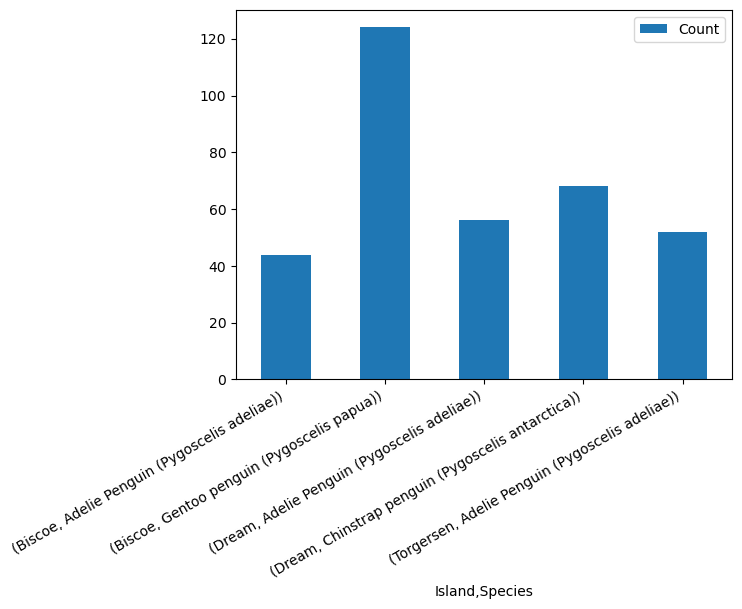

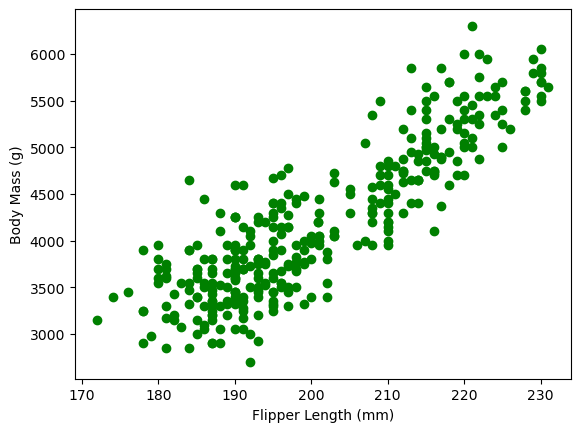

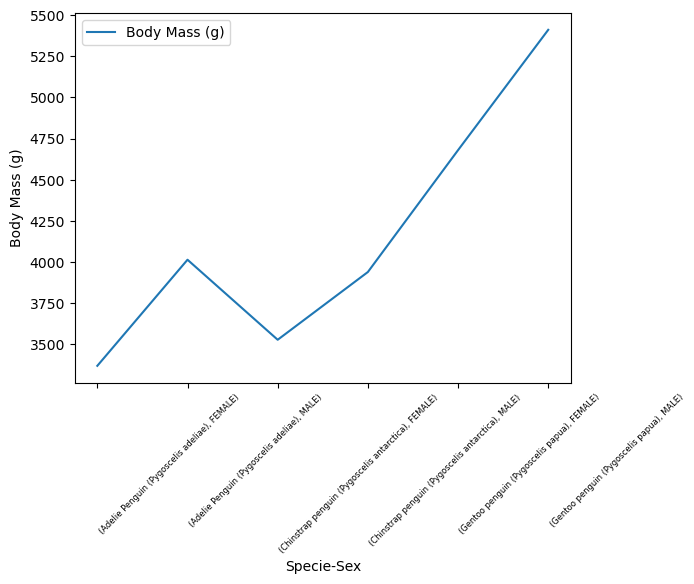

In [11]:
#1º cargamos el dataset y modificaciones hechas anteriormente, que nos valgan para el ejercicio.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

Ruta = Path(r"C:\proyecto-faust\M02_Python_Librerias_Big_Data\U2_Libreria_Pandas\Ejercicios_clase_pandas\penguins.csv")
df = pd.read_csv(Ruta)

df = df.drop("Delta 15 N (o/oo)", axis = "columns").drop("Delta 13 C (o/oo)", axis = "columns")

df["Comments"] = df["Comments"].fillna("No Comments")
df["Culmen Length (mm)"] = df["Culmen Length (mm)"].fillna(df["Culmen Length (mm)"].mean())
df["Culmen Depth (mm)"] = df["Culmen Depth (mm)"].fillna(df["Culmen Depth (mm)"].mean())
df["Flipper Length (mm)"] = df["Flipper Length (mm)"].fillna(df["Flipper Length (mm)"].mean())
df["Body Mass (g)"] = df["Body Mass (g)"].fillna(df["Body Mass (g)"].mean())

df["Sex"] = df["Sex"].astype("category")
sex = df["Sex"].describe()["top"]
df["Sex"] = df["Sex"].fillna(sex)

df["Clutch Completion"]= df["Clutch Completion"].astype("category")
df_island = pd.DataFrame(df.groupby(["Island","Species"])["Island"].count()).rename(columns ={"Island":"Count"})

#2º Generamos un grafico de barras en base al dataframe "df_island" con .plot.bar() y cambiaremos la leyenda con plt.xticks
# Utilizaremos los parametros " rotation = ", " ha = " para cambiar la direccion y "fontsize = " para el tamaño de fuente
# Nos saltamos el uso de matplotlib y su configuracion de graficos en este ejemplo.

df_island.plot.bar()
plt.xticks (rotation = 30, ha = "right", fontsize = 10)

#3º Generamos un grafico de dispersion siguiendo estos pasos
    #1º Generamos una figura nueva mediante figure.plt()
    #2º mediante plt.scatter() eligiendo Ejes: x = Flipper Length (mm) / y = Body Mass (g)
    #3º Incluimos titulos a los ejes mediante xlabel / ylabel

fig_1 = plt.figure()
plt.scatter(x = df["Flipper Length (mm)"], y = df["Body Mass (g)"], color = "green")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")

#4º Generaremos un grafico de lineas siguiendo estos pasos:
    #1º Haremos el filtrado, creando un dataframe, lueggo una agrupacion mediante .groupby(["Species", "Sex"]) y calculamos la media del peso ["Body Mass (g)"].mean()
    #2º Generamos un grafico de lineas mediante .plot(kind ="line")
    #3º Rotamos los titulos y el tamaño con .xticks(rotation =, ha=, fontsize =) y los nombres de los titulos con xlabel, ylabel.

df_2 = pd.DataFrame(df.groupby(["Species", "Sex"])["Body Mass (g)"].mean())
df_2.plot(kind ="line")
plt.xticks(rotation = 45, ha= "left", fontsize = 6)
plt.xlabel("Specie-Sex")
plt.ylabel("Body Mass (g)")